# 9 Bondad de Ajuste 

La pruebas de bondad de ajuste se utilizan para determinar si una muestra de datos proviene de una población con una distribución de probabilidad específica. De este modo buscamos estudiar constrastes del tipo siguiente:

$H_0:$ La distribución de $X$ es del tipo $f_0$

$H_1:$ La distribución de $X$ no es del tipo $f_0$

## 9.1 Pruebas Gráficas


1. Histogramas
   
2. Q-Q-Plots

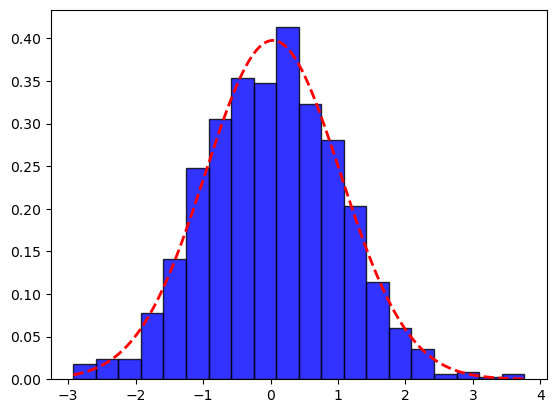

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

datos_observados = stats.norm.rvs(loc=0, scale=1, size=1000)
media_observada = np.mean(datos_observados)
desviacion_observada = np.std(datos_observados)

x = np.linspace(np.min(datos_observados), np.max(datos_observados), 1000)
densidad_normal = stats.norm.pdf(x, loc=media_observada, scale=desviacion_observada)

plt.hist(datos_observados, bins='scott', density=True, alpha=0.8, color='blue', edgecolor='black')
plt.plot(x, densidad_normal, 'r--', linewidth=2)
plt.show()

## Gráfico de Probabilidad (Q-Q Plot)

### Supongamos que disponemos de un conjunto de observaciones $X_i$, ($i = 1, 2, ..., n$).
### Sea $F$ la función de distribución. El gráfico de probabilidad se construye de acuerdo con los siguientes pasos:

### PASO 1: Ordenar las observaciones de menor a mayor. Cuantiles observados. ($Q_O$)

### PASO 2: Calcular los cuantiles teóricos ($Q_T$) de acuerdo a $F$. 

### PASO 3: Representar el conjunto de puntos $(Q_T, Q_O)$.

### Si los puntos siguen aproximadamente una línea recta, los datos se ajustan bien a la distribución teórica.

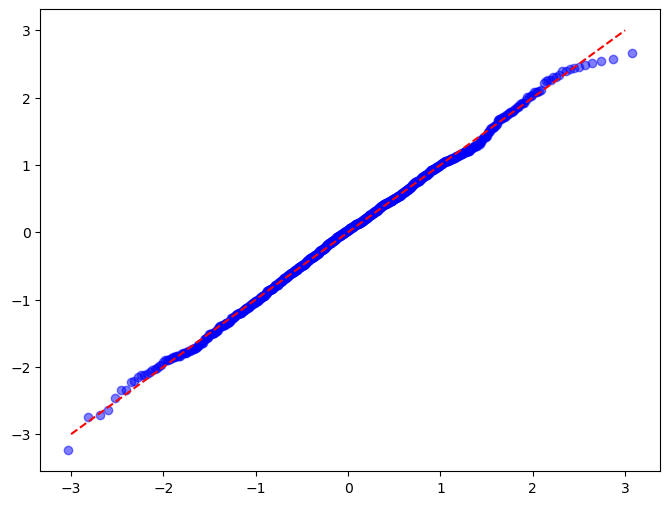

In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

datos_observados = stats.norm.rvs(loc=0, scale=1, size=1000)

secuencia = np.linspace(0, 1, 1000)
cuantiles_observados = np.sort(datos_observados)
cuantiles_esperados = stats.norm.ppf(secuencia, loc=np.mean(datos_observados), scale=np.std(datos_observados))

plt.figure(figsize=(8, 6))
plt.scatter(cuantiles_esperados, cuantiles_observados, color='b', alpha=0.5)
plt.plot([-3, 3], [-3, 3], color='r', linestyle='--')  
plt.show()

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
C:\Users\Hugo Cruz\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


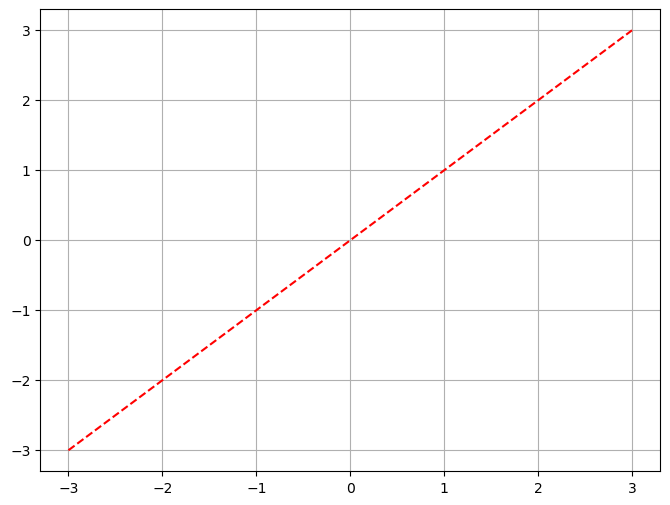

In [18]:
import yfinance as yf

data= yf.download('AAPL', start='2023-01-01', end='2023-12-31')['Close']
rendimientos=np.log(data / data.shift(1)).dropna()

cuantiles_teoricos = np.linspace(0, 1, len(rendimientos))
cuantiles_esperados = stats.norm.ppf(cuantiles_teoricos, loc=np.mean(rendimientos), scale=np.std(rendimientos))
cuantiles_observados = np.sort(rendimientos)


plt.figure(figsize=(8, 6))
plt.scatter(cuantiles_esperados, cuantiles_observados, color='b', alpha=0.5)
plt.plot([-3, 3], [-3, 3], color='r', linestyle='--')
plt.grid(True)
plt.show()

## 9.2 Constraste $\chi^2$ de Pearson

El test $\chi^2$ de Pearson contrasta si una muestra ha sido generada o no con una cierta distribución, cuantificando si sus valores aparecen con una frecuencia cercana a la que sería de esperar si la muestra siguiera esa distribución. 

El test se basa en que, si la hipótesis nula es cierta, las frecuencias empíricas y las frecuencias teóricas son “parecidas”.

El estadístico utilizado es el siguiente:

<img src=chicuad.png>

el cual sigue una distribución chi cuadrada con $k-1$ grados de libertad. El $p$-valor de constraste se cálcula como: $$p=\mathbb{P}(\chi^2_{k-1}>\chi_O).$$

$\textbf{Ejemplo}$ Consideremos que queremos comprobar si un dado está sesgado.

Distribución Teórica:

<img src=dist-teo.png>

Suponga que el dado en prueba se lanza 120 veces y se obtiene:

<img src=frec-emp.png>

Como el número de lanzamientos es 120, la frecuencia para cada clase es 20.

In [4]:
from scipy.stats import chi2

chi2.sf(((20-20)**2/20+(22-20)**2/20+(17-20)**2/20+(18-20)**2/20+(19-20)**2/20+(24-20)**2/20), 5)

0.8888997594927638

Como el p-valor$>0.1$, concluímos que no tenemos evidencias suficientes para rechazar que el dado esté sesgado.

In [5]:
from scipy.stats import chisquare

frecuencias_observadas = [20, 22, 17, 18, 19, 24]
frecuencias_teoricas = [20, 20, 20, 20, 20, 20]

estadistico_chi2, valor_p = chisquare(f_obs=frecuencias_observadas, f_exp=frecuencias_teoricas)

print(estadistico_chi2)
print(valor_p)

1.7000000000000002
0.8888997594927638


$\textbf{Ejemplo}$ Un ingeniero ambiental quiere estudiar el aumento de temperatura del agua a dos kilómetros de los vertidos de agua autorizados de una planta industrial. El responsable de la empresa afirma que estos aumentos de temperatura siguen una ley normal con $\mu=3.5$ décimas de grado C y $\sigma=0.7$ décimas de grado C.

El ingeniero lo pone en entredicho. Para decidirlo, toma una muestra aleatoria de 40 observaciones del aumento de las temperaturas (en décimas de grado) y se obtienen los resultados siguientes:

<img src=tabla_temperatura.png>

In [6]:
from scipy.stats import chi2_contingency

extremos_izquierdos = [-np.inf, 1.95, 2.45, 2.95, 3.45, 3.95, 4.45]
extremos_derechos = [1.95, 2.45, 2.95, 3.45, 3.95, 4.45, np.inf]

frecuencias_empiricas = np.array([2, 1, 4, 15, 10, 5, 3])
n = np.sum(frecuencias_empiricas)

mu = 3.5
sigma = 0.7

probabilidades_teoricas = stats.norm.cdf(extremos_derechos, mu, sigma) - stats.norm.cdf(extremos_izquierdos, mu, sigma)
frecuencias_teoricas = n * probabilidades_teoricas

estadistico_chi2, p_valor = chisquare(f_obs=frecuencias_empiricas, f_exp=frecuencias_teoricas)

print(frecuencias_teoricas)
print(estadistico_chi2)
print(p_valor)

[ 0.53618261  2.13610544  5.96840979 10.22043558 10.73253057  6.91161955
  3.49471646]
8.13366548920104
0.22847332199214795


Conclusión: concluimos que no tenemos evidencias suficientes para rechazar que el aumento de temperatura no siga una distribución normal de parámetros  
$\mu=3.5$ décimas de grado y $\sigma=0.7$ décimas de grado.

$\textbf{Ejercicio}$ Repetir el ejercicio anterior, considerando:

<img src=temp.png>

## 9.3 Test de Kolmogorov-Smirnov (KS)

Sean $x_1,x_2,\ldots, x_n$ los distintos valores observados, y queremos contrastar si ha sido producida por una variable $X$ con distribución $F_X$.

$\bullet$ Ordenamos los valores de la muestra de menor a mayor: $x_{(1)}, x_{(2)},\ldots, x_{(n)}$.

$\bullet$ Calculamos la distribución empírica $F_n$

$\bullet$ Comparar $F_n$ y $F_X$.

Discrepancia máxima: $$D=max\{D_n(x_{(i)}):i=1,2,...n\}$$

<img src=kolmo-dis.png>

Si la hipótesis nula es cierta, la distribución límite de la variable aleatoria $\sqrt{n}D_n$ converge a la distribución de Kolmogorov. 

$\textbf{Ejemplo}$ considere la muestra: 5.84, 4.57, 1.34, 3.58, 1.54, 2.25
Suponga que queremos verificar si esta muestra correpsonde a una población Normal $(3, (1.5)^2)$.

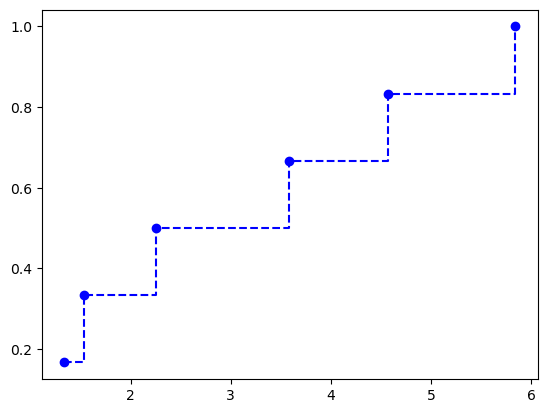

In [7]:
datos = np.array([5.84, 4.57, 1.34, 3.58, 1.54, 2.25])
datos_ordenados = np.sort(datos)

n = len(datos_ordenados)
y_empirica = np.arange(1, n + 1) / n

plt.step(datos_ordenados, y_empirica, where='post', linestyle='--', marker='o', color='b')
plt.show()

<img src=acumu.png>

Cuadro de Discrepancias:

In [8]:
import pandas as pd
from scipy.stats import norm

media = 3
desviacion_estandar = 1.5
cdf_teorica = norm.cdf(datos_ordenados, loc=media, scale=desviacion_estandar) 
D1=np.abs(np.hstack(([0], y_empirica[:-1])) - cdf_teorica)
D2=np.abs(y_empirica - norm.cdf(datos_ordenados, media, desviacion_estandar))

discrepancias = max(max(D1),max(D2)) 

df_discrepancias = pd.DataFrame({
    'Datos': datos_ordenados,
    'ECDF Empírica': y_empirica,
    'CDF Teórica': norm.cdf(datos_ordenados, media, desviacion_estandar),
    'Discrepancia': discrepancias
})

df_discrepancias

,Datos,ECDF Empírica,CDF Teórica,Discrepancia
0,1.34,0.166667,0.134219,0.191462
1,1.54,0.333333,0.165194,0.191462
2,2.25,0.500000,0.308538,0.191462
3,3.58,0.666667,0.650499,0.191462
4,4.57,0.833333,0.852373,0.191462
5,5.84,1.000000,0.970843,0.191462


In [9]:
D=np.max(discrepancias)
D

0.19146246127401312

Por lo tanto $D_O=0.19$. Usando una tabla del test KS.

<img src=tabla.png>

Conclusión: no tenemos indicios suficientes para rechazar que la muestra se distribuya según una distribución normal $(3, (1.5)^2)$. 

### En python hay una función que realiza todo el proceso anterior, se encuentra en la biblioteca SciPy: kstest.

In [10]:
from scipy.stats import kstest

estadistico_ks, p_valor = kstest(datos, 'norm', args=(media, desviacion_estandar))

In [11]:
estadistico_ks

0.19146246127401312

In [12]:
p_valor

0.949984104983571

## 9.3 Shapiro-Wilks

Un inconveniente común al test de K-S es que, si bien pueden usarse con muestras pequeñas, se comportan mal con muestras grandes.

In [13]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
titanic['fare'].isna().sum()

0

In [15]:
datos_titanic=titanic['fare'].values

In [16]:
from scipy.stats import shapiro

estadistico, p_valor = shapiro(datos_titanic)

print(estadistico)
print(p_valor)

0.5218913010396559
1.0840444395829658e-43


### Nota Final. Otras pruebas de normalidad son: Anderson-Darling (anderson()) y D’Agostino-Pearson (normaltest()).